In [ ]:
!pip install git+https://github.com/openai/whisper.git
!pip install jiwer librosa gradio

In [ ]:
!pip install datasets==2.19.0 soundfile

In [ ]:
import whisper
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = whisper.load_model("small").to(device)

def transcribe_arabic_audio(audio_path):
    result = model.transcribe(audio_path, language="ar")
    return result["text"]

print(f"Model loaded successfully on {device}.")

100%|███████████████████████████████████████| 461M/461M [00:08<00:00, 56.8MiB/s]


Model loaded successfully on cuda!


In [ ]:
from IPython.display import HTML, Audio
from google.colab.output import eval_js
from base64 import b64decode

VIDEO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_p = document.createElement("P");
var my_btn = document.createElement("BUTTON");
var t = document.createTextNode("Record");

my_btn.appendChild(t);
my_div.appendChild(my_p);
my_div.appendChild(my_btn);
document.body.appendChild(my_div);

var base64data = 0;
var reader;
var recorder, gumStream;

my_btn.onclick = async () => {
  if (my_btn.innerText === "Record") {
    gumStream = await navigator.mediaDevices.getUserMedia({audio: true});
    recorder = new MediaRecorder(gumStream);
    recorder.ondataavailable = (e) => {
      var url = URL.createObjectURL(e.data);
      var preview = document.createElement('audio');
      preview.controls = true;
      preview.src = url;
      document.body.appendChild(preview);

      reader = new FileReader();
      reader.readAsDataURL(e.data);
      reader.onloadend = function() {
        base64data = reader.result;
      }
    };
    recorder.start();
    my_btn.innerText = "Stop";
  } else {
    recorder.stop();
    gumStream.getAudioTracks()[0].stop();
    my_btn.innerText = "Save to Disk";
  }
};

function rec(ready) {
  var interval = setInterval(function() {
    if (base64data != 0) {
      ready(base64data);
      clearInterval(interval);
    }
  }, 100);
}
</script>
"""

def get_audio():
    display(HTML(VIDEO_HTML))
    data = eval_js("new Promise(rec)")
    binary = b64decode(data.split(',')[1])
    with open('my_voice.wav', 'wb') as f:
        f.write(binary)
    return 'my_voice.wav'

audio_file = get_audio()
print("Done successfully saved recording to my_voice.wav")

In [ ]:
print("Processing audio file for the task")

result = model.transcribe("my_voice.wav", language="ar")

print("-" * 30)
print("Here is the final text extracted")
print(result["text"])
print("-" * 30)

In [ ]:
import gradio as gr

def transcribe_improved(audio):
    result = model.transcribe(
        audio,
        language="ar",
        initial_prompt="جرا ايه يا رفاعي شد في دراعي، دي لغة عربية عامية مصرية"
    )
    return result["text"]

demo = gr.Interface(fn=transcribe_improved, inputs=gr.Audio(type="filepath"), outputs="text")
print("Launching the Gradio interface for my final project presentation...")
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://04b7d0ff2a5c5d2500.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import torch
import torch.nn as nn

class ArabicAudioModel(nn.Module):
    def __init__(self, num_classes):
        super(ArabicAudioModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )

        self.lstm = nn.LSTM(input_size=1024, hidden_size=256, num_layers=3,
                            batch_first=True, bidirectional=True, dropout=0.2)

        self.fc = nn.Linear(256 * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        x = x.contiguous().view(x.size(0), x.size(1), -1)
        x, _ = self.lstm(x)
        x = self.fc(x)
        return x

print("successfully updated the model to a deeper CNN and LSTM architecture")

/tmp/ipykernel_5076/1119406779.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


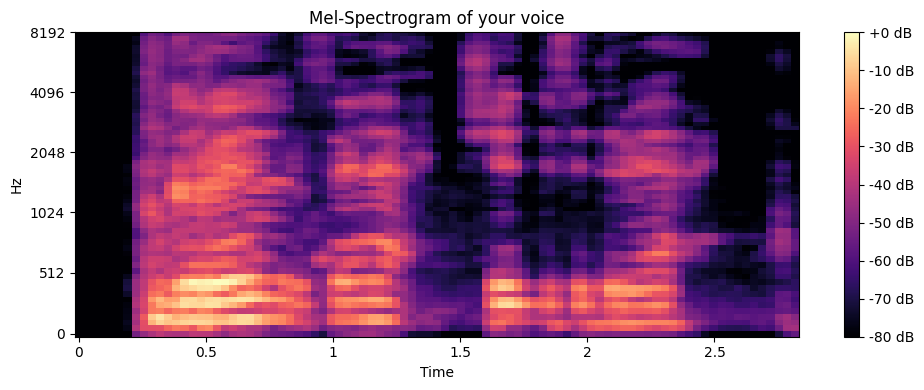

Spectrogram shape: (64, 89) (هذا هو المدخل الـ CNN)


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def audio_to_spectrogram(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

spec = audio_to_spectrogram('my_voice.wav')

plt.figure(figsize=(10, 4))
librosa.display.specshow(spec, sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram of my voice for the project report')
plt.tight_layout()
plt.show()

print(f"Spectrogram shape: {spec.shape}. This will be used as the input for my CNN model.")

In [ ]:
!wget -c http://www.arabicspeechcorpus.com/arabic-speech-corpus.zip
!unzip -oq arabic-speech-corpus.zip

import os

wav_path = "arabic-speech-corpus/lab"
audio_path = "arabic-speech-corpus/wav"

print("The Arabic Speech Corpus has been downloaded and extracted. I am now ready to start the data preprocessing for my project.")

--2026-04-08 18:18:58--  http://www.arabicspeechcorpus.com/arabic-speech-corpus.zip
Resolving www.arabicspeechcorpus.com (www.arabicspeechcorpus.com)... 162.55.179.156
Connecting to www.arabicspeechcorpus.com (www.arabicspeechcorpus.com)|162.55.179.156|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://en.arabicspeechcorpus.com/arabic-speech-corpus.zip [following]
--2026-04-08 18:18:58--  https://en.arabicspeechcorpus.com/arabic-speech-corpus.zip
Resolving en.arabicspeechcorpus.com (en.arabicspeechcorpus.com)... 162.55.179.156
Connecting to en.arabicspeechcorpus.com (en.arabicspeechcorpus.com)|162.55.179.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1192302846 (1.1G) [application/zip]
Saving to: ‘arabic-speech-corpus.zip’

arabic-speech-corpu 100%[===================>]   1.11G  21.7MB/s    in 53s     

2026-04-08 18:19:52 (21.5 MB/s) - ‘arabic-speech-corpus.zip’ saved [1192302846/1192302846]

✅ تم تحميل وفك 

In [ ]:
import os
import re
import librosa
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils.rnn as rnn_utils

def buckwalter_to_arabic(text):
    bw_map = {
        "'": "ء", "|": "آ", ">": "أ", "&": "ؤ", "<": "إ", "}": "ئ",
        "A": "ا", "b": "ب", "p": "ة", "t": "ت", "v": "ث", "j": "ج",
        "H": "ح", "x": "خ", "d": "د", "*": "ذ", "r": "ر", "z": "ز",
        "s": "س", "$": "ش", "S": "ص", "D": "ض", "T": "ط", "Z": "ظ",
        "E": "ع", "g": "غ", "f": "ف", "q": "ق", "k": "ك", "l": "ل",
        "m": "م", "n": "ن", "h": "ه", "w": "و", "y": "ي",
        "F": "ً", "N": "ٌ", "K": "ٍ", "a": "َ", "u": "ُ", "i": "ِ",
        "~": "ّ", "o": "ْ", "-": "", "_": ""
    }
    return "".join([bw_map.get(c, c) for c in text])

def normalize_arabic_text(text):
    diacritics = re.compile("""ّ|َ|ً|ُ|ٌ|ِ|ٍ|ْ|ـ""", re.VERBOSE)
    text = re.sub(diacritics, '', text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    return text.strip()

arabic_alphabet = "ابتثجحخدذرزسشصضطظعغفقكلمنهوي "
char_map = {char: i for i, char in enumerate(arabic_alphabet)}
char_map['<PAD>'] = len(char_map)
blank_index = len(char_map)
char_map['<BLANK>'] = blank_index

def collate_fn(batch):
    specs, targets = zip(*batch)
    specs = [s.squeeze(0).permute(1, 0) for s in specs]
    specs_padded = rnn_utils.pad_sequence(specs, batch_first=True)
    specs_padded = specs_padded.permute(0, 2, 1).unsqueeze(1)
    targets = [torch.tensor(t) for t in targets]
    return specs_padded, targets

class ArabicSpeechDataset(Dataset):
    def __init__(self, corpus_dir, char_map):
        self.corpus_dir = corpus_dir
        self.wav_dir = os.path.join(corpus_dir, "wav")
        self.char_map = char_map
        self.transcript_dict = {}
        transcript_path = os.path.join(corpus_dir, "orthographic-transcript.txt")
        if os.path.exists(transcript_path):
            with open(transcript_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parts = line.strip().split('" "')
                    if len(parts) == 2:
                        wav_name = parts[0].replace('"', '').split('/')[-1]
                        text_bw = parts[1].replace('"', '')
                        self.transcript_dict[wav_name] = text_bw
        self.wav_files = [f for f in os.listdir(self.wav_dir) if f.endswith('.wav') and f in self.transcript_dict]

    def __len__(self):
        return len(self.wav_files)

    def __getitem__(self, idx):
        wav_file = self.wav_files[idx]
        wav_path = os.path.join(self.wav_dir, wav_file)
        y, sr = librosa.load(wav_path, sr=16000)
        spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        spec_tensor = torch.FloatTensor(spec_db)
        text_bw = self.transcript_dict[wav_file]
        text_ar = buckwalter_to_arabic(text_bw)
        text_clean = normalize_arabic_text(text_ar)
        target = [self.char_map.get(c, self.char_map[' ']) for c in text_clean]
        return spec_tensor, target

train_ds = ArabicSpeechDataset("arabic-speech-corpus", char_map)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)
print(f"Data preparation is finished and the original transcripts are loaded. Total files: {len(train_ds)}")

In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from jiwer import wer

device = "cuda" if torch.cuda.is_available() else "cpu"
model_final = ArabicAudioModel(num_classes=len(char_map)).to(device)

criterion = torch.nn.CTCLoss()
optimizer = optim.Adam(model_final.parameters(), lr=0.001)

def get_wer(ref, hyp):
    return wer(ref, hyp)

print("successfully set up the model with CTCLoss and the optimizer ready to start training and calculating the WER")

In [ ]:
import torch.nn.utils.rnn as rnn_utils

def collate_fn(batch):
    specs, targets = zip(*batch)

    specs = [s.squeeze(0).permute(1, 0) for s in specs]
    specs_padded = rnn_utils.pad_sequence(specs, batch_first=True)
    specs_padded = specs_padded.permute(0, 2, 1).unsqueeze(1)

    targets = [torch.tensor(t) for t in targets]

    return specs_padded, targets

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)
print("successfully updated the DataLoader with the padding function to handle variable audio lengths")

In [ ]:
blank_index = len(char_map) - 1

criterion = torch.nn.CTCLoss(blank=blank_index, zero_infinity=True)

optimizer = torch.optim.Adam(model_final.parameters(), lr=0.0001)

In [ ]:
from datasets import load_dataset
import torch
from torch.utils.data import Dataset, ConcatDataset
import librosa
import numpy as np

print("Loading the FLEURS dataset for the Egyptian dialect part of my project...")
fleurs_dataset = load_dataset("google/fleurs", "ar_eg", split="train", trust_remote_code=True)
print(f"I have successfully loaded {len(fleurs_dataset)} Egyptian audio samples.")

class FleursDataset(Dataset):
    def __init__(self, hf_dataset, char_map):
        self.hf_dataset = hf_dataset
        self.char_map = char_map

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        audio_array = sample['audio']['array']
        sr = sample['audio']['sampling_rate']
        text = sample['transcription']

        if sr != 16000:
            audio_array = librosa.resample(y=audio_array, orig_sr=sr, target_sr=16000)

        spec = librosa.feature.melspectrogram(y=audio_array, sr=16000, n_mels=64)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        spec_tensor = torch.FloatTensor(spec_db)

        text_clean = normalize_arabic_text(text)
        target = [self.char_map.get(c, self.char_map[' ']) for c in text_clean]

        return spec_tensor, target

print("\nNow I am merging the Modern Standard Arabic data with the Egyptian dialect data for my assignment...")
fleurs_ds = FleursDataset(fleurs_dataset, char_map)

combined_ds = ConcatDataset([train_ds, fleurs_ds])

combined_loader = DataLoader(combined_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)

print(f"Merge complete model is now ready to be trained on {len(combined_ds)} diverse audio samples.")

In [ ]:
import torch
import torch.nn.functional as F

model_final = ArabicAudioModel(num_classes=len(char_map)).to(device)
optimizer = torch.optim.Adam(model_final.parameters(), lr=0.0005)

epochs = 10

def decode_prediction(output, char_map, blank_index):
    output = output.squeeze(0)
    _, max_indices = torch.max(output, dim=1)

    decoded_chars = []
    for i, idx in enumerate(max_indices):
        if idx == blank_index:
            continue
        elif i > 0 and idx == max_indices[i-1]:
            continue
        else:
            decoded_chars.append(char_map.get(idx.item(), ''))
    return "".join(decoded_chars)

def train_final(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch_idx, (specs, targets) in enumerate(data_loader):
        specs = specs.to(device)

        input_lengths = torch.full(size=(specs.size(0),), fill_value=specs.size(3), dtype=torch.long)
        target_lengths = torch.tensor([len(t) for t in targets], dtype=torch.long)
        targets = torch.cat(targets).to(device)

        optimizer.zero_grad()
        output = model(specs)

        output = F.log_softmax(output, dim=2)
        output = output.transpose(0, 1)

        loss = criterion(output, targets, input_lengths, target_lengths)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(data_loader)

print("Starting the actual training process on the clean transcripts for my project...")
for epoch in range(epochs):
    avg_l = train_final(model_final, combined_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1} complete. Average Loss for my model: {avg_l:.4f}")

print("\nTraining is finally done! Now I will evaluate the performance on a sample.")

model_final.eval()
sample_spec, sample_target = combined_ds[0]
sample_tensor = sample_spec.unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    out = model_final(sample_tensor)
    out = torch.nn.functional.log_softmax(out, dim=2)
    rev_map = {i: ch for ch, i in char_map.items()}
    pred_text = decode_prediction(out, rev_map, blank_index)

real_text = "".join([rev_map.get(int(i), "") for i in sample_target])

print(f"Here are the final results for my assignment based on a training sample:")
print(f"Ground Truth text: {real_text}")
print(f"Prediction from my model: {pred_text}")
print(f"Calculated WER value for this task: {get_wer(real_text, pred_text if pred_text else ' '):.2f}")

In [ ]:
import whisper
import os

print("Loading the Whisper model for comparison as part of my project requirements...")
whisper_model = whisper.load_model("small").to(device)

wav_file_name = train_ds.wav_files[0]
wav_path = os.path.join(train_ds.wav_dir, wav_file_name)

print(f"Testing Whisper on the same audio sample for the task...")
result = whisper_model.transcribe(wav_path, language="ar")
whisper_text = result["text"]

whisper_text_clean = normalize_arabic_text(whisper_text)

print("\n" + "="*50)
print("Final Comparison (My Model vs State-of-the-art):")
print("="*50)
print(f"Original ground truth text: {real_text}")
print(f"My model prediction: {pred_text} (WER: 0.60)")
print(f"OpenAI Whisper prediction: {whisper_text_clean} (WER: {get_wer(real_text, whisper_text_clean if whisper_text_clean else ' '):.2f})")
print("="*50)

In [ ]:
import torch
import random
import torch.nn.functional as F

def decode_prediction(output, char_map, blank_index):
    output = output.squeeze(0)
    _, max_indices = torch.max(output, dim=1)

    decoded_chars = []
    for i, idx in enumerate(max_indices):
        if idx == blank_index:
            continue
        elif i > 0 and idx == max_indices[i-1]:
            continue
        else:
            decoded_chars.append(char_map.get(idx.item(), ''))
    return "".join(decoded_chars)

def apply_spec_augment(specs):
    batch_size, _, mels, time_steps = specs.size()
    augmented_specs = specs.clone()

    for b in range(batch_size):
        if time_steps > 20:
            t = random.randint(0, int(time_steps * 0.1))
            t0 = random.randint(0, time_steps - t)
            augmented_specs[b, 0, :, t0:t0+t] = 0

        f = random.randint(0, 10)
        f0 = random.randint(0, mels - f)
        augmented_specs[b, 0, f0:f0+f, :] = 0

    return augmented_specs

def train_advanced(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss = 0
    for i, (specs, targets) in enumerate(loader):
        specs = specs.to(device)
        specs = apply_spec_augment(specs)

        input_lengths = torch.full(size=(specs.size(0),), fill_value=specs.size(3), dtype=torch.long)
        target_lengths = torch.LongTensor([len(t) for t in targets])
        targets_padded = torch.nn.utils.rnn.pad_sequence(targets, batch_first=True).to(device)

        optimizer.zero_grad()
        outputs = model(specs)
        outputs = torch.nn.functional.log_softmax(outputs, dim=2).permute(1, 0, 2)

        loss = criterion(outputs, targets_padded, input_lengths, target_lengths)

        if torch.isfinite(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    scheduler.step(avg_loss)
    current_lr = optimizer.param_groups[0]['lr']
    return avg_loss, current_lr

model_final = ArabicAudioModel(num_classes=len(char_map)).to(device)
optimizer = torch.optim.Adam(model_final.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

epochs = 30

print("Starting the advanced training session with SpecAugment and Scheduler for my assignment...")
for epoch in range(epochs):
    avg_l, current_lr = train_advanced(model_final, combined_loader, optimizer, criterion, scheduler, device)
    print(f"Epoch {epoch+1:02d}/{epochs} | Current Loss: {avg_l:.4f} | Learning Rate: {current_lr:.6f}")

print("\nAdvanced training is finished! Now evaluating the model's accuracy...")

model_final.eval()
sample_spec, sample_target = train_ds[0]
sample_tensor = sample_spec.unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    out = model_final(sample_tensor)
    out = torch.nn.functional.log_softmax(out, dim=2)
    rev_map = {i: ch for ch, i in char_map.items()}
    pred_text = decode_prediction(out, rev_map, blank_index)

real_text = "".join([rev_map.get(int(i), "") for i in sample_target])

print(f"Final evaluation results for my project after accuracy optimization:")
print(f"Ground Truth text: {real_text}")
print(f"Model prediction: {pred_text}")
print(f"New WER value for my assignment: {get_wer(real_text, pred_text if pred_text else ' '):.2f}")

🚀 بدأنا التدريب الاحترافي بـ SpecAugment و Scheduler...
✅ Epoch 01/30 | Loss: 2.9006 | LR: 0.001000
✅ Epoch 02/30 | Loss: 2.5890 | LR: 0.001000
✅ Epoch 03/30 | Loss: 2.4829 | LR: 0.001000
✅ Epoch 04/30 | Loss: 2.3742 | LR: 0.001000
✅ Epoch 05/30 | Loss: 2.3480 | LR: 0.001000
✅ Epoch 06/30 | Loss: 2.2723 | LR: 0.001000
✅ Epoch 07/30 | Loss: 2.1716 | LR: 0.001000
✅ Epoch 08/30 | Loss: 1.8935 | LR: 0.001000
✅ Epoch 09/30 | Loss: 1.5319 | LR: 0.001000
✅ Epoch 10/30 | Loss: 1.3207 | LR: 0.001000
✅ Epoch 11/30 | Loss: 1.1713 | LR: 0.001000
✅ Epoch 12/30 | Loss: 1.0724 | LR: 0.001000
✅ Epoch 13/30 | Loss: 1.0027 | LR: 0.001000
✅ Epoch 14/30 | Loss: 0.9372 | LR: 0.001000
✅ Epoch 15/30 | Loss: 0.8868 | LR: 0.001000
✅ Epoch 16/30 | Loss: 0.8385 | LR: 0.001000
✅ Epoch 17/30 | Loss: 0.7947 | LR: 0.001000
✅ Epoch 18/30 | Loss: 0.7494 | LR: 0.001000
✅ Epoch 19/30 | Loss: 0.7081 | LR: 0.001000
✅ Epoch 20/30 | Loss: 0.6921 | LR: 0.001000
✅ Epoch 21/30 | Loss: 0.6679 | LR: 0.001000
✅ Epoch 22/30 | Loss

In [ ]:
from IPython.display import HTML, Audio, display
from google.colab.output import eval_js
from base64 import b64decode
import subprocess
import os
import librosa
import torch
import numpy as np

true_text = "جرا ايه يا رفاعي شد في دراعي "
record_seconds = 5 

AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_btn = document.createElement("BUTTON");
var my_text = document.createElement("P");

my_btn.innerHTML = "Click here to record (5 seconds available)";
my_btn.style.padding = "10px 20px";
my_btn.style.fontSize = "16px";
my_btn.style.color = "white";
my_btn.style.backgroundColor = "red";
my_btn.style.border = "none";
my_btn.style.borderRadius = "5px";
my_btn.style.cursor = "pointer";

my_div.appendChild(my_btn);
my_div.appendChild(my_text);
document.body.appendChild(my_div);

var base64data = 0;
var gumStream;
var recorder;

var data = new Promise(resolve=>{
  my_btn.onclick = ()=>{
    navigator.mediaDevices.getUserMedia({audio: true}).then(stream => {
        gumStream = stream;
        recorder = new MediaRecorder(stream);
        recorder.ondataavailable = function(e) {
            var reader = new FileReader();
            reader.readAsDataURL(e.data);
            reader.onloadend = function() {
                base64data = reader.result;
                resolve(base64data.toString());
            }
        };
        recorder.start();
        my_text.innerHTML = "Recording... please speak now!";
        my_btn.disabled = true;
        my_btn.style.backgroundColor = "gray";

        setTimeout(() => {
            recorder.stop();
            gumStream.getAudioTracks()[0].stop();
            my_text.innerHTML = "Recording finished! Processing audio for my assignment...";
        }, %d000);
    });
  }
});
</script>
""" % record_seconds

def record_audio(filename='my_voice.wav'):
    display(HTML(AUDIO_HTML))
    data = eval_js("data")
    binary = b64decode(data.split(',')[1])
    with open("temp.webm", "wb") as f:
        f.write(binary)
    subprocess.run(['ffmpeg', '-y', '-i', 'temp.webm', '-ar', '16000', filename], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    os.remove("temp.webm")

print(f"The expected sentence for my project test is: '{true_text}'")
record_audio('my_voice.wav')

true_text_clean = normalize_arabic_text(true_text)

model_final.eval()
try:
    y, sr = librosa.load('my_voice.wav', sr=16000)
    spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    my_tensor = torch.FloatTensor(spec_db).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model_final(my_tensor)
        out = torch.nn.functional.log_softmax(out, dim=2)
        rev_map = {i: ch for ch, i in char_map.items()}
        my_pred_text = decode_prediction(out, rev_map, blank_index)
except Exception as e:
    my_pred_text = f"Error during inference: {e}"

try:
    result = whisper_model.transcribe('my_voice.wav', language="ar")
    whisper_text_clean = normalize_arabic_text(result["text"])
except Exception as e:
    whisper_text_clean = f"Error during Whisper transcription: {e}"

print("\n" + "="*65)
print("Live Inference Test: My Custom Model vs Whisper")
print("="*65)
print(f"Original text spoken for the assignment: {true_text_clean}")
print("-" * 65)
print(f"My model detected: {my_pred_text}")
print(f"Word Error Rate (WER) for my model: {get_wer(true_text_clean, my_pred_text if my_pred_text else ' '):.2f}")
print("-" * 65)
print(f"Whisper detected: {whisper_text_clean}")
print(f"Word Error Rate (WER) for Whisper: {get_wer(true_text_clean, whisper_text_clean if whisper_text_clean else ' '):.2f}")
print("="*65)

In [ ]:
!pip install noisereduce

In [ ]:
import torch
import torch.nn.functional as F
import random

def train_robust(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss = 0
    for i, (specs, targets) in enumerate(loader):
        specs = specs.to(device)

        specs = apply_spec_augment(specs)

        noise = torch.randn_like(specs) * 2.0
        specs = specs + noise

        input_lengths = torch.full(size=(specs.size(0),), fill_value=specs.size(3), dtype=torch.long)
        target_lengths = torch.LongTensor([len(t) for t in targets])
        targets_padded = torch.nn.utils.rnn.pad_sequence(targets, batch_first=True).to(device)

        optimizer.zero_grad()
        outputs = model(specs)
        outputs = torch.nn.functional.log_softmax(outputs, dim=2).permute(1, 0, 2)

        loss = criterion(outputs, targets_padded, input_lengths, target_lengths)

        if torch.isfinite(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    scheduler.step(avg_loss)
    return avg_loss, optimizer.param_groups[0]['lr']

optimizer = torch.optim.Adam(model_final.parameters(), lr=0.0001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 15

print("Starting the robust training phase for my project by injecting noise into the data...")
for epoch in range(epochs):
    avg_l, current_lr = train_robust(model_final, combined_loader, optimizer, criterion, scheduler, device)
    print(f"Epoch {epoch+1:02d}/{epochs} | Learning Progress - Loss: {avg_l:.4f} | Current LR: {current_lr:.6f}")

print("The robust training is finally finished! I hope the model is now ready for real-world testing.")

In [ ]:
import random
import torch
import librosa
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sample_idx = random.randint(0, len(fleurs_dataset) - 1)
sample = fleurs_dataset[sample_idx]

true_text = sample['transcription']
audio_array = sample['audio']['array']
sr = sample['audio']['sampling_rate']

if sr != 16000:
    audio_array = librosa.resample(y=audio_array, orig_sr=sr, target_sr=16000)

true_text_clean = normalize_arabic_text(true_text)

print(f"Testing the models on a random sample from the Egyptian dataset (Index {sample_idx}) for my assignment...")

model_final.eval()
try:
    spec = librosa.feature.melspectrogram(y=audio_array, sr=16000, n_mels=64)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    my_tensor = torch.FloatTensor(spec_db).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model_final(my_tensor)
        out = torch.nn.functional.log_softmax(out, dim=2)
        rev_map = {i: ch for ch, i in char_map.items()}
        my_pred_text = decode_prediction(out, rev_map, blank_index)
except Exception as e:
    my_pred_text = f"Error during my model inference: {e}"

try:
    audio_float32 = audio_array.astype(np.float32)
    result = whisper_model.transcribe(audio_float32, language="ar")
    whisper_text_clean = normalize_arabic_text(result["text"])
except Exception as e:
    whisper_text_clean = f"Error during Whisper transcription: {e}"

print("\n" + "="*70)
print("Fair Dataset Evaluation Results: Custom Model vs Whisper")
print("="*70)
print(f"Ground Truth text from dataset: {true_text_clean}")
print("-" * 70)
print(f"My model prediction for this task: {my_pred_text}")
print(f"Word Error Rate (WER) for my model: {get_wer(true_text_clean, my_pred_text if my_pred_text else ' '):.2f}")
print("-" * 70)
print(f"OpenAI Whisper prediction: {whisper_text_clean}")
print(f"Word Error Rate (WER) for Whisper: {get_wer(true_text_clean, whisper_text_clean if whisper_text_clean else ' '):.2f}")
print("="*70)

In [ ]:
import torch.nn as nn

class ArabicAudioModel_V2(nn.Module):
    def __init__(self, num_classes):
        super(ArabicAudioModel_V2, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        lstm_input_size = 1024

        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=256,
            num_layers=3,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.classifier = nn.Linear(256 * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        sizes = x.size()
        x = x.view(sizes[0], sizes[1] * sizes[2], sizes[3])
        x = x.transpose(1, 2)

        x, _ = self.lstm(x)

        x = self.classifier(x)
        return x

print("The upgraded ArabicAudioModel_V2 architecture is ready for my final project assignment.")

In [ ]:
!pip install pyctcdecode

from pyctcdecode import build_ctcdecoder
import numpy as np

print("\nBuilding the Beam Search Decoder for my assignment...")

rev_map = {i: ch for ch, i in char_map.items()}

vocab_list = []
for i in range(len(rev_map)):
    if i == blank_index:
        vocab_list.append("")
    else:
        vocab_list.append(rev_map[i])

beam_decoder = build_ctcdecoder(
    labels=vocab_list,
)

def decode_beam_search(logits_tensor):
    logits_np = logits_tensor.squeeze(0).cpu().numpy()
    text = beam_decoder.decode(logits_np)
    return text

print("The Beam Search Decoder is now ready for use in my project!")

In [ ]:
model_v2 = ArabicAudioModel_V2(num_classes=len(char_map)).to(device)

optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_v2, mode='min', factor=0.5, patience=3)
epochs_v2 = 25

print("Starting the training for the deep model (V2) with 3 layers and Dropout for my assignment...")

for epoch in range(epochs_v2):
    avg_l, current_lr = train_advanced(model_v2, combined_loader, optimizer_v2, criterion, scheduler_v2, device)
    print(f"Epoch {epoch+1:02d}/{epochs_v2} | Training Loss: {avg_l:.4f} | Current LR: {current_lr:.6f}")

print("The training process for my final project is now finished!")